In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

In [72]:
lake = 'neuchatel'
folder_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(folder_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(folder_path, "outputs_swirl", "eddy_statistics")
os.makedirs(output_folder, exist_ok=True)

# Import lvl1 catalogue

In [73]:
lvl1_csv_path = os.path.join(input_folder, "lvl1.csv")

In [74]:
df_lvl1 = pd.read_csv(lvl1_csv_path)
df_lvl1 = df_lvl1.set_index('id', drop=False)
df_lvl1['date'] = pd.to_datetime(df_lvl1['date'])

In [75]:
df_lvl1 = df_lvl1[df_lvl1['date'] >= '2025-03-01']

In [76]:
lake_mask = np.load(os.path.join(folder_path, "grid", "mask_lake.npy"))

In [77]:
depths = pd.read_csv(os.path.join(folder_path, "grid", "depths.csv"))

# Number of eddies

nb_eddy = df_lvl1.groupby(['date'])['id'].count()

df_lvl1.groupby(['date'])['id'].count().iloc[7010]

plt.figure(figsize=(8,5))
nb_eddy.plot()
plt.ylim(bottom=0)
plt.ylabel('Number of eddies [-]')
plt.xlabel("")
plt.grid(False)
plt.savefig(os.path.join(output_folder, "eddy_numbers.png"))

In [78]:
def filter_by_depths(df, depth_min, depth_max):
    depth_filter = (
            (abs(df['depth_min_[m]']) >= abs(depth_max)) &
            (abs(df['depth_max_[m]']) <= abs(depth_min))
    )

    return df[depth_filter]

In [79]:
depth_min = -11
depth_max = -0.25
df_lvl1_filtered_by_depth = filter_by_depths(df_lvl1, depth_min, depth_max).copy()

In [80]:
nb_eddy_by_depth = df_lvl1_filtered_by_depth.groupby(['date'])['id'].count()

In [81]:
df_lake = pd.read_csv(os.path.join(input_folder, "lake_characteristics.csv"))

In [82]:
volume_lake_slice_in_km3 = df_lake[(df_lake['depth_[m]'] > depth_min) & (df_lake['depth_[m]'] < depth_max) & (df_lake['time_index'] == df_lake.iloc[0]['time_index'])]['volume_slice_[m3]'].sum()/1e9

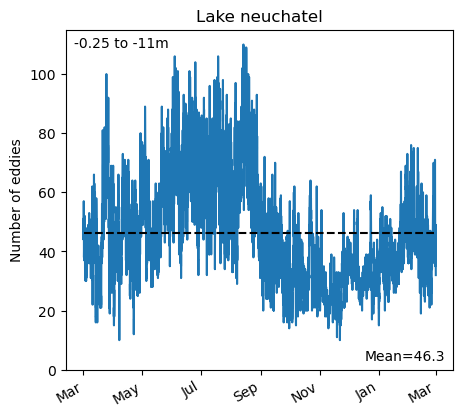

In [83]:
fig, ax = plt.subplots(figsize=(5, 5))
nb_eddy_by_depth.plot()

plt.hlines(nb_eddy_by_depth.mean(),
           nb_eddy_by_depth.index[0],
           nb_eddy_by_depth.index[-1],
           linestyles='dashed',
           color='black')
plt.text(0.98,0.02,f'Mean={nb_eddy_by_depth.mean():.1f}', transform=plt.gca().transAxes, ha='right', va='bottom')

plt.ylim(bottom=0)
plt.ylabel("Number of eddies")
plt.text(0.02, 0.98, f'{depth_max} to {depth_min}m', transform=plt.gca().transAxes, ha='left', va='top')
plt.xlabel("")
plt.title(f'Lake {lake}')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.savefig(os.path.join(output_folder, f"eddy_numbers_{depth_min}-{depth_max}m.png"))

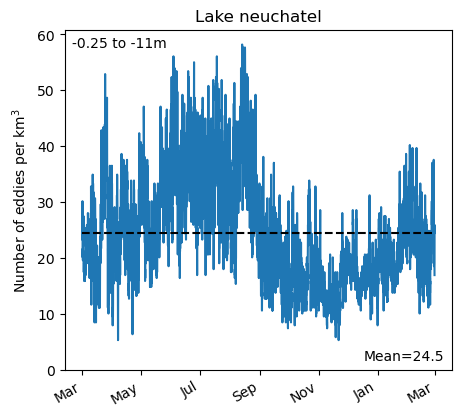

In [84]:
fig, ax = plt.subplots(figsize=(5, 5))
(nb_eddy_by_depth/volume_lake_slice_in_km3).plot()

plt.hlines(nb_eddy_by_depth.mean()/volume_lake_slice_in_km3,
           nb_eddy_by_depth.index[0],
           nb_eddy_by_depth.index[-1],
           linestyles='dashed',
           color='black')
plt.text(0.98,0.02,f'Mean={nb_eddy_by_depth.mean()/volume_lake_slice_in_km3:.1f}', transform=plt.gca().transAxes, ha='right', va='bottom')

plt.ylim(bottom=0)
plt.ylabel("Number of eddies per km$^3$")
plt.text(0.02, 0.98, f'{depth_max} to {depth_min}m', transform=plt.gca().transAxes, ha='left', va='top')
plt.xlabel("")
plt.title(f'Lake {lake}')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.savefig(os.path.join(output_folder, f"eddy_numbers_per_km3_{depth_min}-{depth_max}m.png"))

In [99]:
nb_eddy_by_depth.reset_index().to_csv(os.path.join(output_folder, f"eddy_numbers_{depth_min}-{depth_max}m.csv"))

In [100]:
df_lvl1_filtered_by_depth['diameter_[m]'] = np.sqrt(df_lvl1_filtered_by_depth['surface_area_mean_[m2]'] / np.pi)*2

Text(0.5, 1.0, 'Lucerne')

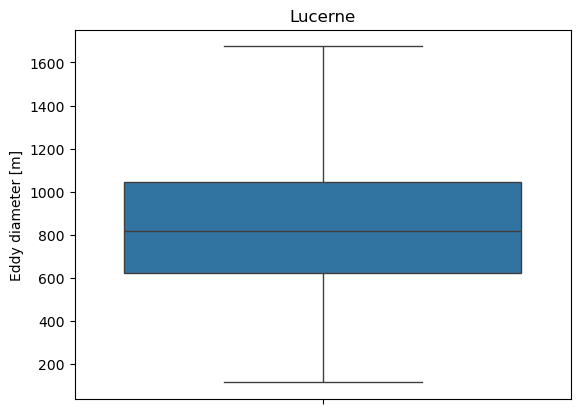

In [101]:
sns.boxplot(data=df_lvl1_filtered_by_depth['diameter_[m]'], showfliers=False)
plt.ylabel("Eddy diameter [m]")
plt.title(f"{lake.capitalize()}")

# Surface statistics

In [102]:
df_lvl1['surface_area_mean_[km2]'] = df_lvl1['surface_area_mean_[m2]'] / 1e6

In [103]:
surface_timeserie = df_lvl1.groupby(['date'])['surface_area_mean_[km2]'].sum()

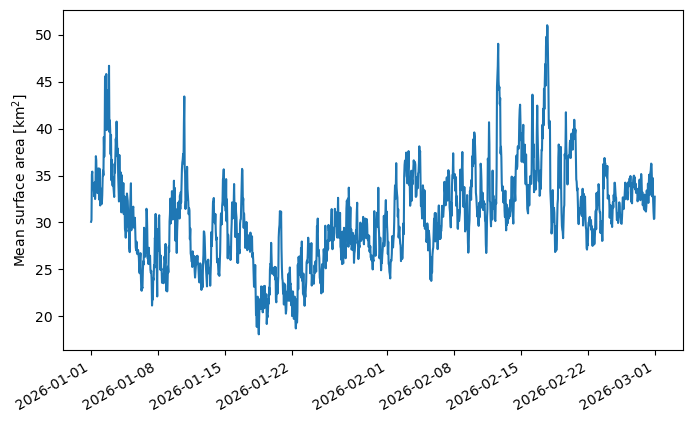

In [104]:
plt.figure(figsize=(8,5))
surface_timeserie.plot()
plt.ylabel("Mean surface area [km$^2$]")
plt.xlabel('')
plt.savefig(os.path.join(output_folder, "surface_timeserie.png"))

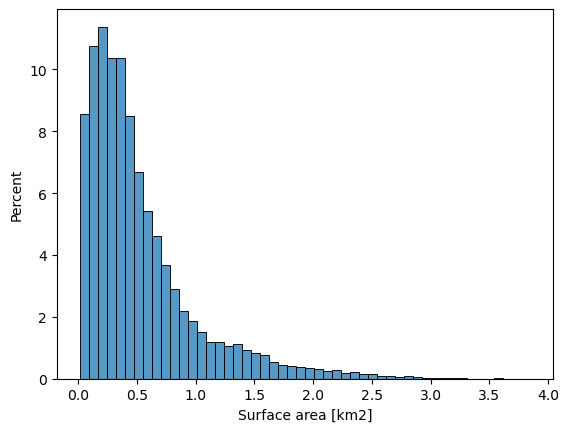

In [105]:
fig, ax = plt.subplots()
sns.histplot(df_lvl1['surface_area_mean_[km2]'][df_lvl1['surface_area_mean_[km2]']<10], bins=50, kde=False, stat='percent')
plt.xlabel("Surface area [km2]")
plt.savefig(os.path.join(output_folder, "surface_statistics.png"))

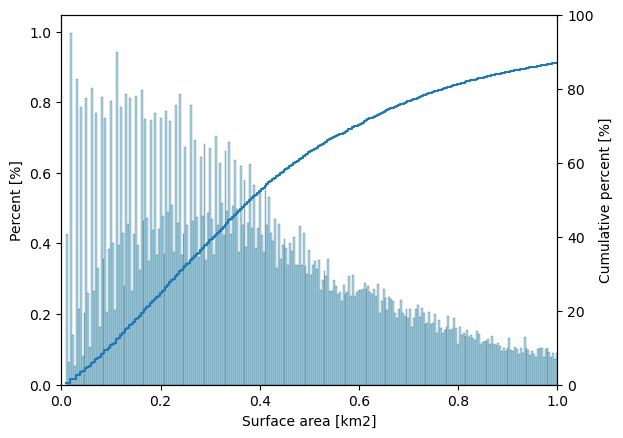

In [106]:
xlim_high = 1

fig, ax = plt.subplots()
plt.xlabel("Surface area [km2]")
plt.xlim(0, xlim_high)
ax.set_ylabel("Percent [%]")

ax2 = ax.twinx()
ax2.set_ylabel("Cumulative percent [%]")
ax2.set_ylim(0, 100)

data = df_lvl1['surface_area_mean_[km2]']
#data = data[data < 10]

sns.histplot(data, bins=1000, stat="percent", color="skyblue", ax=ax)
sns.histplot(data, bins=1000, stat="percent", cumulative=True, element="step", fill=False, ax=ax2)

plt.savefig(os.path.join(output_folder, "surface_statistics_small-eddies.png"))

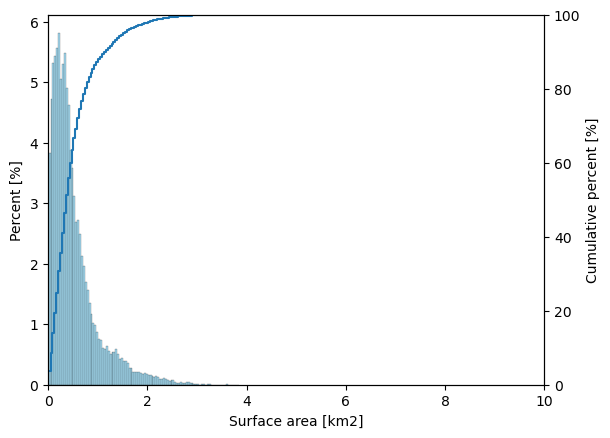

In [107]:
xlim_high = 10

fig, ax = plt.subplots()
plt.xlabel("Surface area [km2]")
plt.xlim(0, xlim_high)
ax.set_ylabel("Percent [%]")

ax2 = ax.twinx()
ax2.set_ylabel("Cumulative percent [%]")
ax2.set_ylim(0, 100)

data = df_lvl1['surface_area_mean_[km2]']
#data = data[data < 10]

sns.histplot(data, bins=100, stat="percent", color="skyblue", ax=ax)
sns.histplot(data, bins=100, stat="percent", cumulative=True, element="step", fill=False, ax=ax2)

plt.savefig(os.path.join(output_folder, "surface_statistics.png"))

# Volume statistics

In [109]:
df_lvl1['volume_[km3]'] = df_lvl1['volume_[m3]'] / 1e9

In [110]:
volume_timeserie = df_lvl1.groupby(['date'])['volume_[km3]'].sum()

In [111]:
volume_timeserie.to_csv(os.path.join(output_folder, 'eddy_volume_timeserie.csv'))

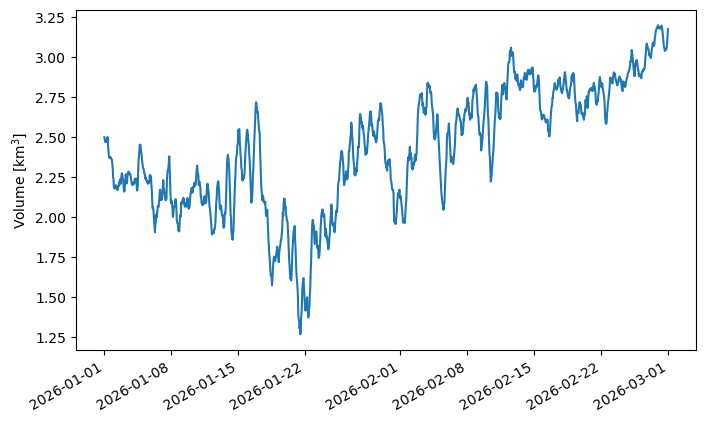

In [112]:
plt.figure(figsize=(8,5))
volume_timeserie.plot()
plt.ylabel("Volume [km$^3$]")
plt.xlabel('')
plt.grid(False)
plt.savefig(os.path.join(output_folder, "volume_timeserie.png"))

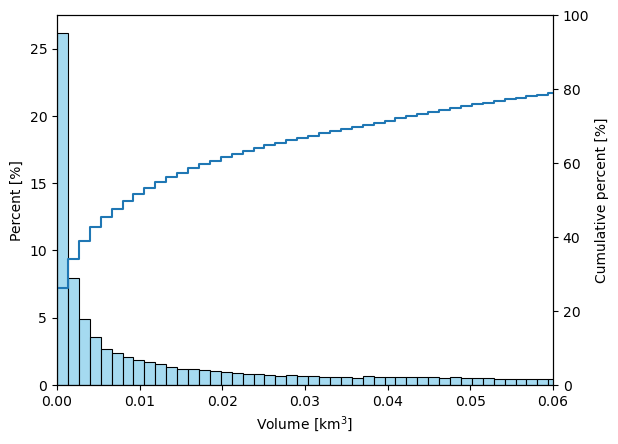

In [34]:
xlim_high = 0.06

fig, ax = plt.subplots()
plt.xlabel("Volume [km$^3$]")
plt.xlim(0, xlim_high)
ax.set_ylabel("Percent [%]")

ax2 = ax.twinx()
ax2.set_ylabel("Cumulative percent [%]")
ax2.set_ylim(0, 100)

data = df_lvl1['volume_[km3]']
#data = data[data < 10]

sns.histplot(data, bins=500, stat="percent", color="skyblue", ax=ax)
sns.histplot(data, bins=500, stat="percent", cumulative=True, element="step", fill=False, ax=ax2)

plt.savefig(os.path.join(output_folder, "volume_statistics.png"))

In [35]:
rho_w = 1000 # kg/m3
df_lvl1['ke_density_[J/kg]'] = 1e6 * df_lvl1['kinetic_energy_eddy_[MJ]']/(df_lvl1['volume_[m3]']*rho_w)

In [36]:
df_lvl1['ke_density_[J/kg]'].to_csv(os.path.join(folder_path, "outputs_swirl", "ke_eddy", "eddy_ke_in_Jperkg.csv"))

OSError: Cannot save file into a non-existent directory: '/storage/alplakes_test/lucerne_test_wind/outputs_swirl/ke_eddy'

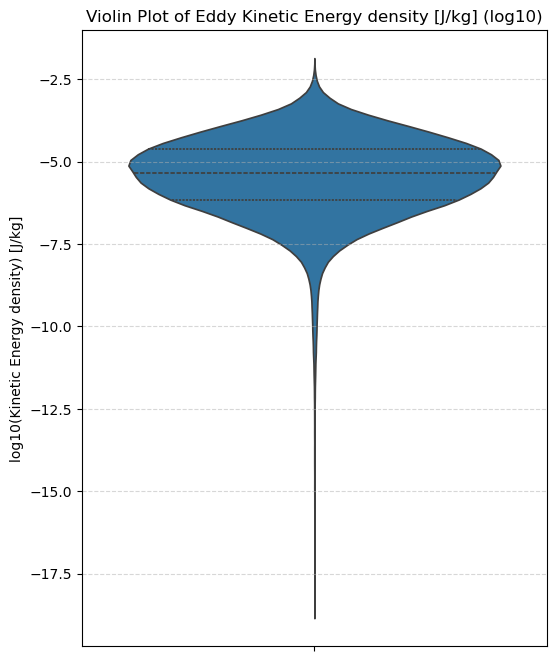

In [ ]:
# Violin plot
plt.figure(figsize=(6, 8))
sns.violinplot(data=np.log10(df_lvl1['ke_density_[J/kg]'][df_lvl1['ke_density_[J/kg]']>0]),
               inner='quartile',
               color='tab:blue')  # inner='quartile' shows median & quartiles
plt.title('Violin Plot of Eddy Kinetic Energy density [J/kg] (log10)')
plt.ylabel('log10(Kinetic Energy density) [J/kg]')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Height statistics

In [37]:
depths = pd.read_csv(os.path.join(folder_path, "grid", "depths.csv"))

In [38]:
depths.head()

,depth_index,depth_[m],thickness_[m]
0,0.0,-0.25,-0.5
1,1.0,-0.75,-0.5
2,2.0,-1.25,-0.5
3,3.0,-1.75,-0.5
4,4.0,-2.25,-0.5


In [39]:
df_lvl1['height_[m]'] = df_lvl1['depth_max_[m]'] - df_lvl1['depth_min_[m]']

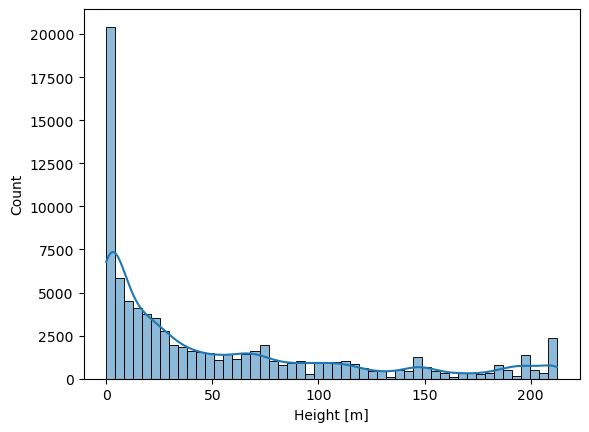

In [40]:
fig, ax = plt.subplots()
sns.histplot(df_lvl1['height_[m]'], bins=50, kde=True)
plt.xlabel("Height [m]")
plt.savefig(os.path.join(output_folder, "height_statistics.png"))

# Depth statistics

In [41]:
df_lvl1['depth_max_[m]']

id
0         -0.250000
1         -0.250000
2         -0.250000
3         -0.250000
4         -0.250000
            ...    
83712   -151.699997
83713   -156.699997
83714   -176.699997
83715   -181.600006
83716   -191.199997
Name: depth_max_[m], Length: 83717, dtype: float64

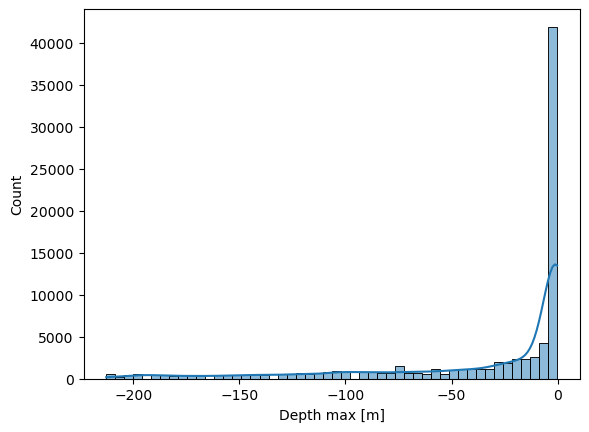

In [42]:
fig, ax = plt.subplots()
sns.histplot(df_lvl1['depth_max_[m]'], bins=50, kde=True)
plt.xlabel("Depth max [m]")
#ax.xaxis.set_major_locator(MultipleLocator(1))
plt.savefig(os.path.join(output_folder, "depth_max.png"))

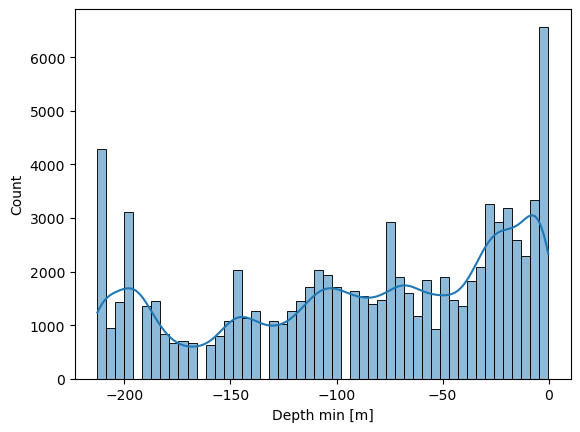

In [43]:
fig, ax = plt.subplots()
sns.histplot(df_lvl1['depth_min_[m]'], bins=50, kde=True)
plt.xlabel("Depth min [m]")
#ax.xaxis.set_major_locator(MultipleLocator(1))
plt.savefig(os.path.join(output_folder, "depth_min.png"))

In [44]:
df_lvl1['time_index'].max()

10175.0

In [45]:
import numpy as np

# Define depth grid
depth_bins = np.arange(0, -60, -1)  # adjust max depth + resolution

occupancy = np.zeros([int(df_lvl1['time_index'].max()+1), len(depth_bins)-1])

for _, row in df_lvl1.iterrows():
    mask = (depth_bins[:-1] >= row["depth_min_[m]"]) & (depth_bins[:-1] <= row["depth_max_[m]"])
    occupancy[int(row['time_index']), mask] += 1

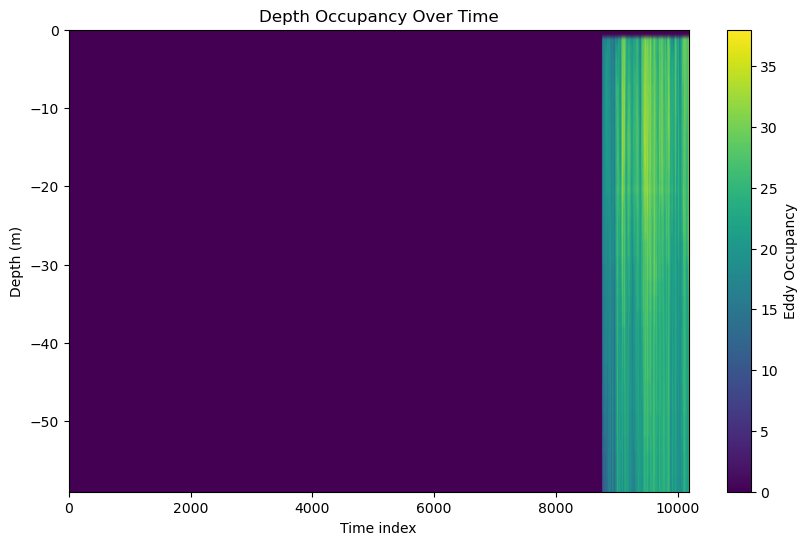

In [46]:
plt.figure(figsize=(10, 6))

plt.imshow(
    occupancy.T,
    aspect='auto',
    origin='lower',
    extent=[
        0, occupancy.shape[0],          # time axis
        depth_bins[0], depth_bins[-1]   # depth axis
    ]
)

plt.colorbar(label='Eddy Occupancy')
plt.gca().invert_yaxis()
plt.xlabel('Time index')
plt.ylabel('Depth (m)')
plt.title('Depth Occupancy Over Time')

plt.show()